In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary stats:\n")
display(df.describe())

Shape: (20640, 9)

Columns:
 ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Summary stats:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640,)


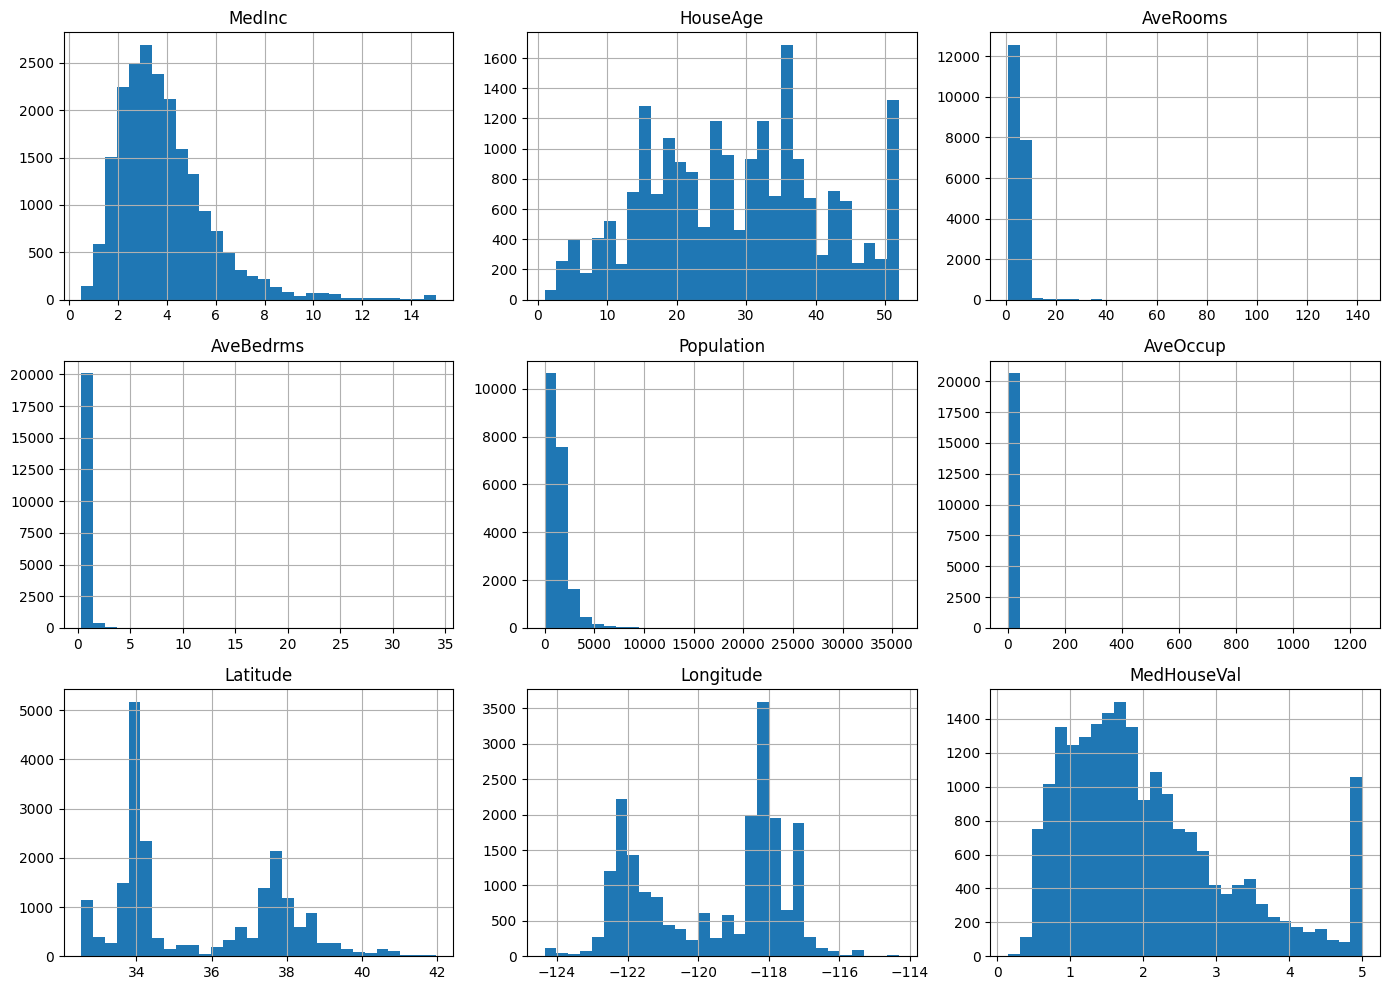

In [5]:
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

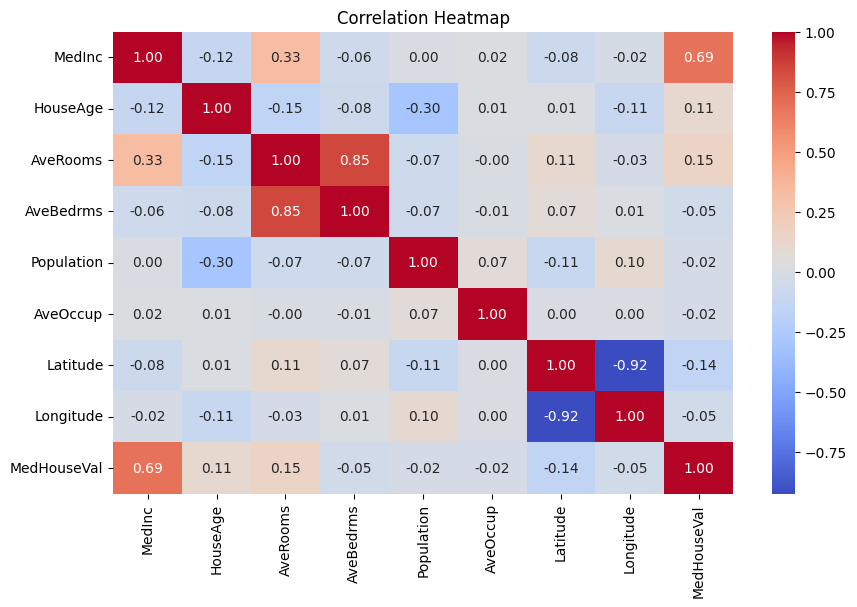

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (16512, 8)
X_test : (4128, 8)


In [8]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

In [9]:
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results")
print("MAE :", round(lr_mae, 4))
print("RMSE:", round(lr_rmse, 4))
print("R2  :", round(lr_r2, 4))

Linear Regression Results
MAE : 0.5332
RMSE: 0.7456
R2  : 0.5758


In [10]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [11]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R2  :", round(rf_r2, 4))

Random Forest Results
MAE : 0.3268
RMSE: 0.504
R2  : 0.8062


In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.533200,0.745581,0.575788
1,Random Forest,0.326812,0.503960,0.806186


In [13]:
cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores
print("Linear Regression CV RMSE scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())

Linear Regression CV RMSE scores: [0.69631786 0.78898504 0.80387217 0.73702076 0.70333835]
Mean CV RMSE: 0.7459068363518111


In [14]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
MedInc,0.525886
AveOccup,0.138055
Latitude,0.088647
Longitude,0.088307
HouseAge,0.054355
AveRooms,0.044449
Population,0.030693
AveBedrms,0.029608


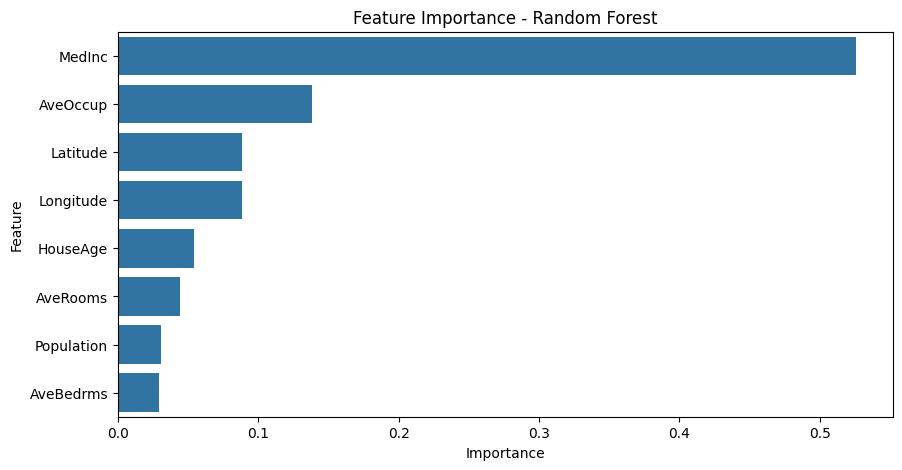

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

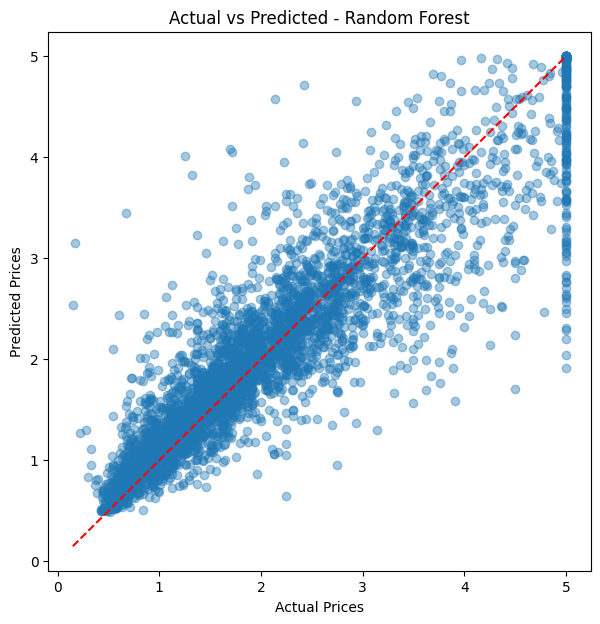

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_preds, alpha=0.4)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted - Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

In [17]:
sample = X_test.iloc[[0]]
sample_prediction = rf_model.predict(sample)[0]

print("Sample features:\n")
display(sample)

print("Actual value   :", y_test.iloc[0])
print("Predicted value:", sample_prediction)

Sample features:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01


Actual value   : 0.477
Predicted value: 0.49443
